# Credit Risk Prediction - Final Task - Briliant Vilendro Kastilong

# 1. Business Understanding
1.1 Background

Perusahaan multifinance menghadapi tantangan dalam menentukan apakah seorang calon peminjam memiliki risiko gagal membayar pinjaman (default). Keputusan pemberian kredit yang kurang tepat dapat meningkatkan jumlah kredit bermasalah (Non-Performing Loan/NPL), sehingga berdampak pada kerugian finansial perusahaan.

Sebagai Data Scientist di ID/X Partners, tujuan utama proyek ini adalah membangun model machine learning yang mampu memprediksi risiko kredit berdasarkan karakteristik peminjam dan informasi pinjaman. Model yang dihasilkan diharapkan dapat membantu perusahaan mengambil keputusan kredit secara lebih cepat, konsisten, dan akurat.

1.2 Business Problem

Perusahaan ingin mengurangi risiko kerugian akibat pemberian pinjaman kepada peminjam yang berpotensi gagal membayar.

Masalah utama yang ingin diselesaikan:

Bagaimana mengidentifikasi sejak awal apakah seorang peminjam memiliki risiko kredit yang tinggi sehingga perusahaan dapat mengurangi kemungkinan terjadinya gagal bayar?

1.3 Objectives

Tujuan dari proyek ini adalah:

Memahami karakteristik data pinjaman.
Mengidentifikasi faktor-faktor yang memengaruhi risiko kredit.
Membangun model machine learning untuk mengklasifikasikan status kredit menjadi Good Loan atau Bad Loan.
Membandingkan performa beberapa algoritma machine learning.
Memberikan rekomendasi bisnis berdasarkan hasil analisis.

1.4 Business Metrics

Keberhasilan proyek diukur berdasarkan kemampuan model dalam membedakan antara peminjam berisiko rendah dan tinggi.

Metrik evaluasi yang digunakan meliputi:

Accuracy
Precision
Recall
F1-Score
ROC-AUC Score

Dalam kasus credit risk, Recall untuk kelas Bad Loan akan menjadi perhatian utama karena perusahaan lebih ingin mengidentifikasi sebanyak mungkin peminjam yang berpotensi gagal bayar.

## Import Library

In [ ]:
# ============================
# Basic Library
# ============================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ============================
# Visualization
# ============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# ============================
# Machine Learning
# ============================

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Models

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

## Load Dataset

In [ ]:
# Load dataset

df = pd.read_csv("loan_data_2007_2014.csv", low_memory=False)

# Menampilkan 5 data pertama
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Menampilkan ukuran dataset

print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

Jumlah Baris : 466285
Jumlah Kolom : 75


In [ ]:
# Membuat salinan dataset agar data asli tetap aman

loan = df.copy()

# Data Understanding

## Melihat Struktur Dataset

In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

Dataset terdiri dari 466.285 observasi dengan 75 atribut yang
terdiri dari data numerik, kategorikal, tanggal, dan identifier.

Tahap ini dilakukan untuk memahami struktur dataset sebelum
melakukan proses pembersihan data.

## Menampilkan Shape Dataset

In [ ]:
print("="*40)
print("Dataset Shape")
print("="*40)

print(f"Rows    : {loan.shape[0]}")
print(f"Columns : {loan.shape[1]}")

Dataset Shape
Rows    : 466285
Columns : 75


## Melihat Nama Kolom

In [ ]:
loan.columns.tolist()

['Unnamed: 0',
 'id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_a

## Statistik Deskriptif

In [ ]:
loan.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,466285.0,2.331420e+05,1.346050e+05,0.00,1.165710e+05,2.331420e+05,3.497130e+05,4.662840e+05
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01


Statistik deskriptif memberikan informasi mengenai:

- rata-rata
- median
- minimum
- maksimum
- kuartil
- standar deviasi

yang berguna untuk mendeteksi nilai tidak wajar maupun outlier.

## Statistik Data Kategorikal

In [ ]:
loan.describe(include='object').T

,count,unique,top,freq
term,466285,2,36 months,337953
grade,466285,7,B,136929
sub_grade,466285,35,B3,31686
emp_title,438697,205475,Teacher,5399
emp_length,445277,11,10+ years,150049
home_ownership,466285,6,MORTGAGE,235875
verification_status,466285,3,Verified,168055
issue_d,466285,91,Oct-14,38782
loan_status,466285,9,Current,224226
pymnt_plan,466285,2,n,466276


# Pemeriksaan Missing Value

In [ ]:
missing = pd.DataFrame({
    'Missing Values': loan.isnull().sum(),
    'Percentage': (loan.isnull().sum()/len(loan))*100
})

missing = missing.sort_values(
    by='Percentage',
    ascending=False
)

missing = missing[
    missing['Missing Values'] > 0
]

missing

,Missing Values,Percentage
max_bal_bc,466285,100.000000
open_rv_24m,466285,100.000000
inq_fi,466285,100.000000
open_rv_12m,466285,100.000000
il_util,466285,100.000000
mths_since_rcnt_il,466285,100.000000
total_bal_il,466285,100.000000
open_il_24m,466285,100.000000
open_il_12m,466285,100.000000
open_il_6m,466285,100.000000


## Visualisasi Missing Value

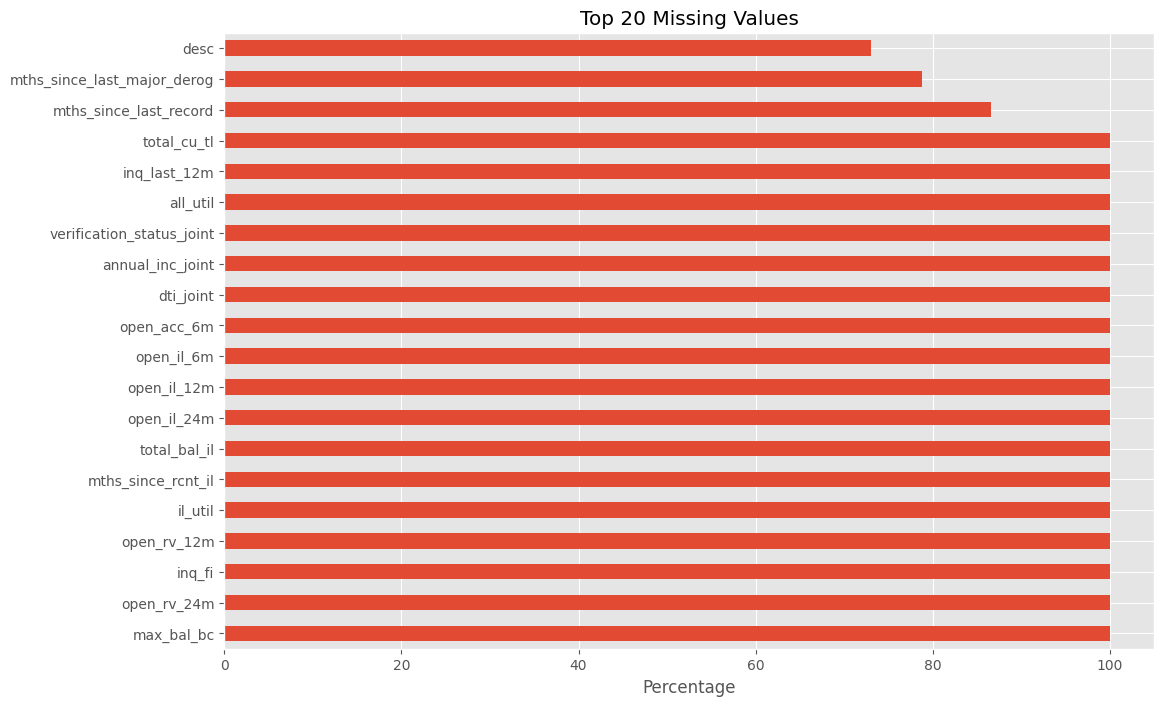

In [ ]:
plt.figure(figsize=(12,8))

missing['Percentage'].head(20).plot(
    kind='barh'
)

plt.title("Top 20 Missing Values")

plt.xlabel("Percentage")

plt.show()

Beberapa fitur memiliki missing value yang sangat tinggi.

Kolom dengan persentase missing value di atas 80%
akan dipertimbangkan untuk dihapus karena informasi
yang tersedia terlalu sedikit untuk memberikan nilai
prediktif yang baik.

# Duplicate Data

In [ ]:
duplicate = loan.duplicated().sum()

print("Duplicate Data :", duplicate)

Duplicate Data : 0


Tidak ditemukan data duplikat sehingga tidak diperlukan
proses penghapusan duplicate.

## Pemeriksaan Target

In [ ]:
loan['loan_status'].value_counts()

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


In [ ]:
loan['loan_status'].value_counts(normalize=True)*100

,proportion
loan_status,
Current,48.087757
Fully Paid,39.619332
Charged Off,9.109236
Late (31-120 days),1.479782
In Grace Period,0.674695
Does not meet the credit policy. Status:Fully Paid,0.426349
Late (16-30 days),0.261214
Default,0.178432
Does not meet the credit policy. Status:Charged Off,0.163205


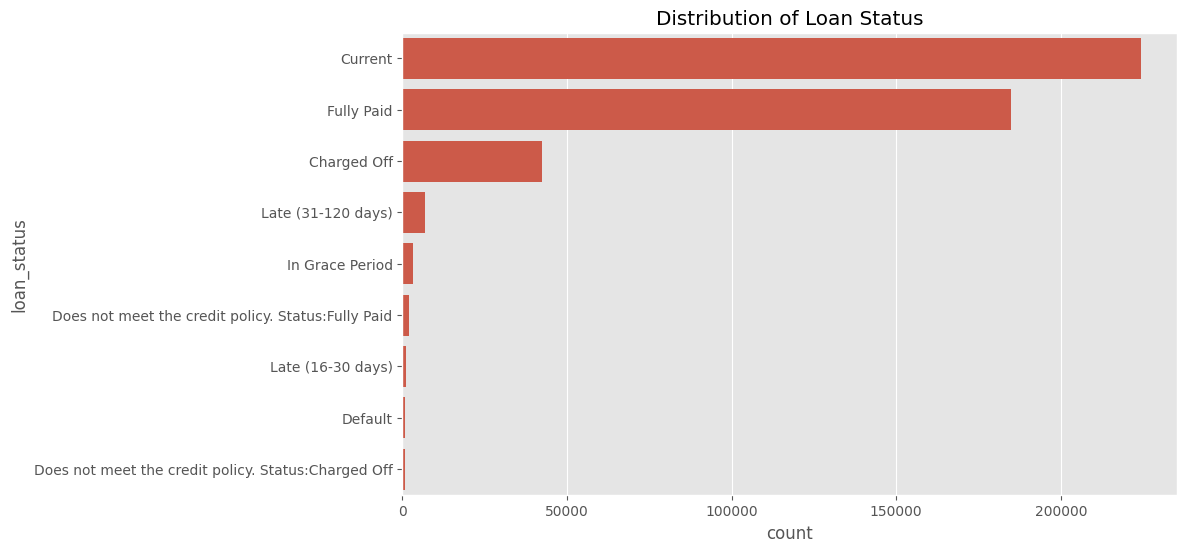

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='loan_status',
    data=loan,
    order=loan['loan_status'].value_counts().index
)

plt.title("Distribution of Loan Status")

plt.show()

Di sinilah kita mulai memahami target, biasanya hasilnya seperti :

Current

Fully Paid

Charged Off

Late

Default

In Grace Period

Does not meet credit policy

Belum diubah menjadi GOOD/BAD karena kita masih memahami datanya.

## Memahami Tipe Data

In [ ]:
loan.dtypes.value_counts()

,count
float64,46
object,22
int64,7


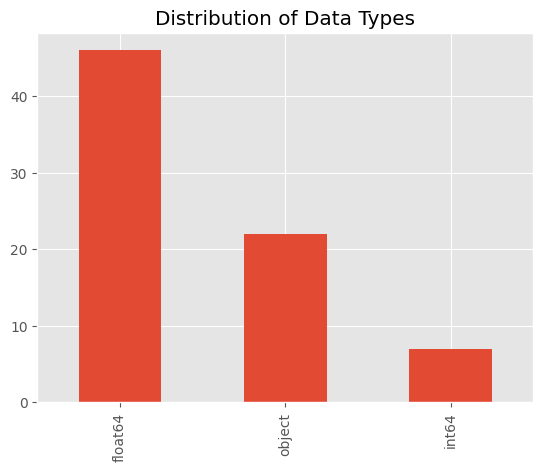

In [ ]:
loan.dtypes.value_counts().plot(
    kind='bar'
)

plt.title("Distribution of Data Types")

plt.show()

## Analisis Kolom Berdasarkan Data Dictionary

| Feature     | Description                    | Type        |
| ----------- | ------------------------------ | ----------- |
| loan_amnt   | Jumlah pinjaman yang diajukan  | Numeric     |
| funded_amnt | Jumlah pinjaman yang disetujui | Numeric     |
| term        | Lama pinjaman                  | Category    |
| int_rate    | Tingkat bunga                  | Numeric (%) |
| installment | Cicilan bulanan                | Numeric     |
| grade       | Grade kredit                   | Category    |
| annual_inc  | Pendapatan tahunan             | Numeric     |
| purpose     | Tujuan pinjaman                | Category    |
| dti         | Debt to Income Ratio           | Numeric     |
| loan_status | Status pinjaman                | Target      |


## Mengelompokkan Feature

In [ ]:
categorical_features = loan.select_dtypes(
    include='object'
).columns.tolist()

numerical_features = loan.select_dtypes(
    include=['int64','float64']
).columns.tolist()

In [ ]:
print("Categorical Feature :", len(categorical_features))

print("Numerical Feature :", len(numerical_features))

Categorical Feature : 22
Numerical Feature : 53


## Ringkasan Data Understanding

Berdasarkan tahap Data Understanding diperoleh beberapa temuan awal:

1. Dataset terdiri dari 466.285 baris dan 75 kolom.

2. Dataset terdiri atas fitur numerik dan kategorikal.

3. Beberapa fitur memiliki missing value yang sangat tinggi
(>80%) sehingga akan dipertimbangkan untuk dihapus pada tahap
Data Preparation.

4. Tidak ditemukan duplicate data (jika hasil pemeriksaan memang nol).

5. Kolom loan_status akan digunakan sebagai dasar pembentukan
target klasifikasi Good Loan dan Bad Loan.

6. Tahap berikutnya adalah Data Cleaning untuk menangani
missing value, menghapus fitur yang tidak relevan, serta
melakukan transformasi data sebelum analisis lebih lanjut.

# Data Cleaning & Feature Engineering

## 3.1 Membuat Copy Dataset

In [ ]:
# copy dataset khusus preprocessing
loan_clean = loan.copy()

## Menampilkan Missing Value Kembali

In [ ]:
missing = pd.DataFrame({
    'Missing Values': loan_clean.isnull().sum(),
    'Percentage': (loan_clean.isnull().sum()/len(loan_clean))*100
})

missing = missing.sort_values(
    by='Percentage',
    ascending=False
)

missing[missing['Missing Values']>0]

,Missing Values,Percentage
max_bal_bc,466285,100.000000
open_rv_24m,466285,100.000000
inq_fi,466285,100.000000
open_rv_12m,466285,100.000000
il_util,466285,100.000000
mths_since_rcnt_il,466285,100.000000
total_bal_il,466285,100.000000
open_il_24m,466285,100.000000
open_il_12m,466285,100.000000
open_il_6m,466285,100.000000


Tahap ini dilakukan kembali agar kita mengetahui fitur mana saja
yang membutuhkan perlakuan khusus sebelum proses pemodelan.

# Menghapus Kolom dengan Missing Value Sangat Tinggi

In [ ]:
missing_cols = missing[
    missing['Percentage'] > 80
].index.tolist()

missing_cols

['max_bal_bc',
 'open_rv_24m',
 'inq_fi',
 'open_rv_12m',
 'il_util',
 'mths_since_rcnt_il',
 'total_bal_il',
 'open_il_24m',
 'open_il_12m',
 'open_il_6m',
 'open_acc_6m',
 'dti_joint',
 'annual_inc_joint',
 'verification_status_joint',
 'all_util',
 'inq_last_12m',
 'total_cu_tl',
 'mths_since_last_record']

In [ ]:
loan_clean.drop(
    columns=missing_cols,
    inplace=True
)

Kolom dengan missing value di atas 80% dihapus karena sebagian besar
nilainya kosong sehingga informasi yang dikandung sangat terbatas
dan berpotensi menambah noise pada model.

## Menghapus Kolom Identifier

In [ ]:
identifier_columns = [
    'id',
    'member_id',
    'url'
]

In [ ]:
loan_clean.drop(
    columns=identifier_columns,
    inplace=True,
    errors='ignore'
)

Kolom identifier hanya berfungsi sebagai identitas unik dan
tidak memiliki hubungan dengan risiko kredit.

## Menghapus Kolom Teks Bebas

In [ ]:
text_columns = [
    'desc',
    'title',
    'emp_title'
]

loan_clean.drop(
    columns=text_columns,
    inplace=True,
    errors='ignore'
)

Alasannya:

- terlalu banyak kategori

- sulit diproses

- tidak relevan untuk baseline model

## Menghapus Kolom yang Berpotensi Data Leakage

In [ ]:
leakage_columns = [
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'out_prncp',
    'out_prncp_inv',
    'next_pymnt_d',
    'last_credit_pull_d'
]

loan_clean.drop(
    columns=leakage_columns,
    inplace=True,
    errors='ignore'
)

Kolom-kolom tersebut tidak boleh digunakan untuk prediksi sebelum pinjaman diberikan.

Karena jika digunakan model akan "curang" (data leakage).

## Membersihkan Kolom Presentase

In [ ]:
percentage_columns = [
    'int_rate',
    'revol_util'
]

for col in percentage_columns:

    loan_clean[col] = (
        loan_clean[col]
        .astype(str)
        .str.replace('%','')
        .astype(float)
    )

Persentase diubah menjadi tipe numerik agar dapat digunakan
oleh algoritma machine learning.

## Membersihkan Kolom Term

In [ ]:
loan_clean['term'] = (
    loan_clean['term']
    .str.replace(' months','')
    .astype(int)
)

## Membersihkan Employment Length

In [ ]:
loan_clean['emp_length'] = (
    loan_clean['emp_length']
    .str.replace(r'\+ years','',regex=True)
    .str.replace(r' years','',regex=True)
    .str.replace(r' year','',regex=True)
    .str.replace('< 1','0')
)

loan_clean['emp_length'] = pd.to_numeric(
    loan_clean['emp_length'],
    errors='coerce'
)

## Konversi Kolom Tanggal

In [ ]:
date_columns = [
    'issue_d',
    'earliest_cr_line'
]

for col in date_columns:

    loan_clean[col] = pd.to_datetime(
        loan_clean[col],
        format='%b-%Y',
        errors='coerce'
    )

## Menentukan Target (Good Loan vs Bad Loan)

In [ ]:
loan_clean['loan_status'].value_counts()

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


In [ ]:
good_status = [
    'Fully Paid',
    'Current'
]

bad_status = [
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'Does not meet the credit policy. Status:Charged Off',
    'In Grace Period'
]

loan_clean = loan_clean[
    loan_clean['loan_status'].isin(
        good_status + bad_status
    )
]

loan_clean['target'] = loan_clean['loan_status'].apply(
    lambda x: 0 if x in good_status else 1
)

Target dibentuk menjadi klasifikasi biner:

0 = Good Loan

1 = Bad Loan

Pendekatan ini sesuai dengan tujuan bisnis yaitu
memprediksi risiko kredit sebelum pinjaman diberikan.

# Drop Kolom Target Lama

In [ ]:
loan_clean.drop(
    columns='loan_status',
    inplace=True
)

## Missing Value Setelah Cleaning

In [ ]:
loan_clean.isnull().sum().sort_values(
    ascending=False
).head(20)

,0
earliest_cr_line,464297
issue_d,464297
mths_since_last_major_derog,365323
mths_since_last_delinq,249447
total_rev_hi_lim,68288
tot_cur_bal,68288
tot_coll_amt,68288
emp_length,20989
revol_util,306
collections_12_mths_ex_med,78


## Imputasi Missing Value

In [ ]:
# numerik
numeric_columns = loan_clean.select_dtypes(
    include=['int64','float64']
).columns

for col in numeric_columns:

    loan_clean[col].fillna(
        loan_clean[col].median(),
        inplace=True
    )

In [ ]:
# kategori
categorical_columns = loan_clean.select_dtypes(
    include='object'
).columns

for col in categorical_columns:

    loan_clean[col].fillna(
        loan_clean[col].mode()[0],
        inplace=True
    )

## Cek Missing Value Lagi

In [ ]:
loan_clean.isnull().sum().sum()

np.int64(928594)

In [ ]:
missing_after = loan_clean.isnull().sum()

missing_after = missing_after[missing_after > 0]

missing_after.sort_values(ascending=False)

,0
issue_d,464297
earliest_cr_line,464297


In [ ]:
loan[['issue_d','earliest_cr_line']].head(10)

,issue_d,earliest_cr_line
0,Dec-11,Jan-85
1,Dec-11,Apr-99
2,Dec-11,Nov-01
3,Dec-11,Feb-96
4,Dec-11,Jan-96
5,Dec-11,Nov-04
6,Dec-11,Jul-05
7,Dec-11,Jan-07
8,Dec-11,Apr-04
9,Dec-11,Sep-04


In [ ]:
date_columns = [
    'issue_d',
    'earliest_cr_line'
]

for col in date_columns:

    loan_clean[col] = pd.to_datetime(
        loan_clean[col],
        errors='coerce'
    )

## Cek Apakah Konversi Berhasil

In [ ]:
# Mengecek jumlah missing value pada kolom tanggal

loan_clean[['issue_d', 'earliest_cr_line']].isnull().sum()

,0
issue_d,464297
earliest_cr_line,464297


## Cek Tipe Data

In [ ]:
loan_clean[['issue_d','earliest_cr_line']].dtypes

,0
issue_d,datetime64[ns]
earliest_cr_line,datetime64[ns]


## Buat Feature Engineering Tanggal

In [ ]:
# tahun pinjaman
loan_clean['issue_year'] = loan_clean['issue_d'].dt.year

In [ ]:
# bulan pinjaman
loan_clean['issue_month'] = loan_clean['issue_d'].dt.month

In [ ]:
# tahun pertama memiliki riwayat kredit
loan_clean['credit_history_year'] = loan_clean['earliest_cr_line'].dt.year

In [ ]:
# lama riwayat kredit
loan_clean['credit_history_length'] = (
    loan_clean['issue_year'] -
    loan_clean['credit_history_year']
)

In [ ]:
# Hapus Kolom Tanggal Asli
loan_clean.drop(
    columns=['issue_d','earliest_cr_line'],
    inplace=True
)

In [ ]:
loan_clean[['issue_year',
            'issue_month',
            'credit_history_year',
            'credit_history_length']].head()

,issue_year,issue_month,credit_history_year,credit_history_length
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


In [ ]:
print("Jumlah kolom:", len(loan_clean.columns))
print(loan_clean.columns.tolist())

Jumlah kolom: 40
['Unnamed: 0', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'target', 'issue_year', 'issue_month', 'credit_history_year', 'credit_history_length']


In [ ]:
# Menghapus kolom index yang tidak diperlukan
loan_clean.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [ ]:
print("="*60)
print("FINAL DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {loan_clean.shape[0]}")
print(f"Columns : {loan_clean.shape[1]}")

print("\nMissing Values:")
print(loan_clean.isnull().sum().sum())

print("\nDuplicate:")
print(loan_clean.duplicated().sum())

FINAL DATASET OVERVIEW
Rows    : 464297
Columns : 39

Missing Values:
1857188

Duplicate:
0


In [ ]:
loan[['issue_d', 'earliest_cr_line']].head(10)

,issue_d,earliest_cr_line
0,Dec-11,Jan-85
1,Dec-11,Apr-99
2,Dec-11,Nov-01
3,Dec-11,Feb-96
4,Dec-11,Jan-96
5,Dec-11,Nov-04
6,Dec-11,Jul-05
7,Dec-11,Jan-07
8,Dec-11,Apr-04
9,Dec-11,Sep-04


In [ ]:
print(loan['issue_d'].unique()[:10])

['Dec-11' 'Nov-11' 'Oct-11' 'Sep-11' 'Aug-11' 'Jul-11' 'Jun-11' 'May-11'
 'Apr-11' 'Mar-11']


In [ ]:
# Mengambil kembali kolom tanggal dari dataset asli

loan_clean['issue_d'] = loan['issue_d']
loan_clean['earliest_cr_line'] = loan['earliest_cr_line']

In [ ]:
# Konversi ke datetime

loan_clean['issue_d'] = pd.to_datetime(
    loan_clean['issue_d'].str.strip(),
    format='%b-%y',
    errors='coerce'
)

loan_clean['earliest_cr_line'] = pd.to_datetime(
    loan_clean['earliest_cr_line'].str.strip(),
    format='%b-%y',
    errors='coerce'
)

In [ ]:
print(loan_clean[['issue_d','earliest_cr_line']].isnull().sum())

loan_clean[['issue_d','earliest_cr_line']].head()

issue_d             0
earliest_cr_line    3
dtype: int64


,issue_d,earliest_cr_line
0,2011-12-01,1985-01-01
1,2011-12-01,1999-04-01
2,2011-12-01,2001-11-01
3,2011-12-01,1996-02-01
4,2011-12-01,1996-01-01


In [ ]:
# Feature Engineering dari kolom tanggal

loan_clean['issue_year'] = loan_clean['issue_d'].dt.year
loan_clean['issue_month'] = loan_clean['issue_d'].dt.month

loan_clean['credit_history_year'] = (
    loan_clean['earliest_cr_line'].dt.year
)

loan_clean['credit_history_length'] = (
    loan_clean['issue_year'] -
    loan_clean['credit_history_year']
)

In [ ]:
loan_clean['credit_history_year'].fillna(
    loan_clean['credit_history_year'].median(),
    inplace=True
)

loan_clean['credit_history_length'].fillna(
    loan_clean['credit_history_length'].median(),
    inplace=True
)

In [ ]:
loan_clean.drop(
    columns=['issue_d', 'earliest_cr_line'],
    inplace=True
)

In [ ]:
missing = pd.DataFrame({
    'Missing': loan_clean.isnull().sum(),
    'Percent': loan_clean.isnull().mean() * 100
})

missing[missing['Missing'] > 0].sort_values(
    by='Missing',
    ascending=False
)

,Missing,Percent


In [ ]:
print("="*60)
print("FINAL DATASET CHECK")
print("="*60)

print(f"Shape              : {loan_clean.shape}")
print(f"Duplicate Rows     : {loan_clean.duplicated().sum()}")
print(f"Total Missing      : {loan_clean.isnull().sum().sum()}")

print("\nData Types")
print(loan_clean.dtypes.value_counts())

FINAL DATASET CHECK
Shape              : (464297, 39)
Duplicate Rows     : 0
Total Missing      : 0

Data Types
float64    21
object     10
int64       6
int32       2
Name: count, dtype: int64


# Exploratory Data Analysis (EDA)

## 4.1 Distribusi Target
Tahap pertama EDA adalah memahami distribusi target (Good Loan dan Bad Loan).

Distribusi ini penting untuk mengetahui apakah dataset seimbang (balanced) atau tidak, karena ketidakseimbangan kelas dapat memengaruhi performa model machine learning.

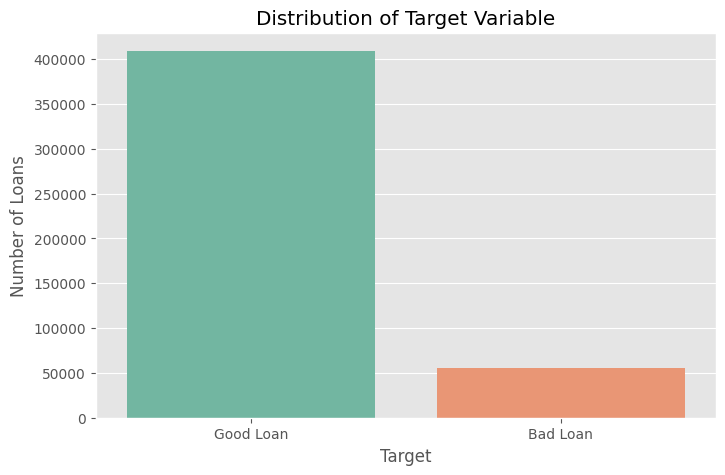

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='target',
    data=loan_clean,
    palette='Set2'
)

plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Number of Loans")

plt.xticks(
    [0,1],
    ['Good Loan','Bad Loan']
)

plt.show()


In [ ]:
target_percent = (
    loan_clean['target']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_percent

,proportion
target,
0,88.08
1,11.92


Sebagian besar pinjaman termasuk kategori Good Loan, sedangkan Bad Loan memiliki proporsi yang lebih kecil. Hal ini menunjukkan dataset tidak sepenuhnya seimbang sehingga metrik seperti Recall, F1-Score, dan ROC-AUC akan lebih informatif dibanding hanya Accuracy.

## 4.2 Distribusi Loan Amount

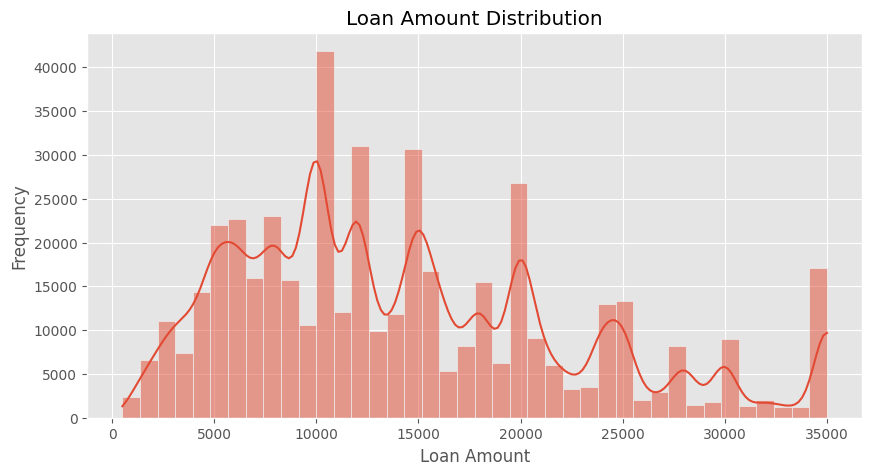

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    loan_clean['loan_amnt'],
    bins=40,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

Analisis ini bertujuan memahami pola jumlah pinjaman yang diajukan oleh peminjam.

In [ ]:
loan_clean['loan_amnt'].describe()

,loan_amnt
count,464297.000000
mean,14340.673211
std,8286.693547
min,500.000000
25%,8000.000000
50%,12000.000000
75%,20000.000000
max,35000.000000


Mayoritas pinjaman berada pada nominal yang relatif kecil hingga menengah. Distribusi miring ke kanan (right-skewed), menunjukkan hanya sebagian kecil peminjam yang mengajukan pinjaman dalam jumlah sangat besar.

## 4.3 Distribusi Interest Rate

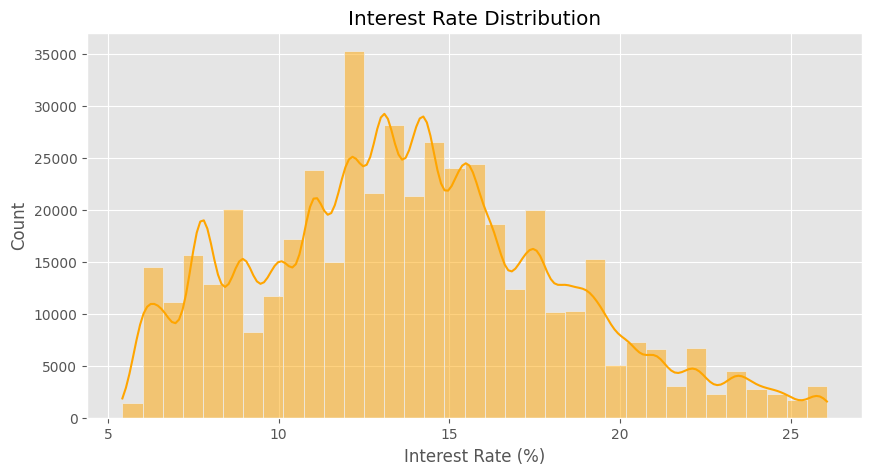

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    loan_clean['int_rate'],
    bins=35,
    kde=True,
    color='orange'
)

plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate (%)")

plt.show()

Tingkat bunga tidak terdistribusi secara merata. Sebagian besar pinjaman berada pada rentang bunga tertentu yang mencerminkan kebijakan penilaian risiko perusahaan.

## 4.4 Distribusi Annual Income

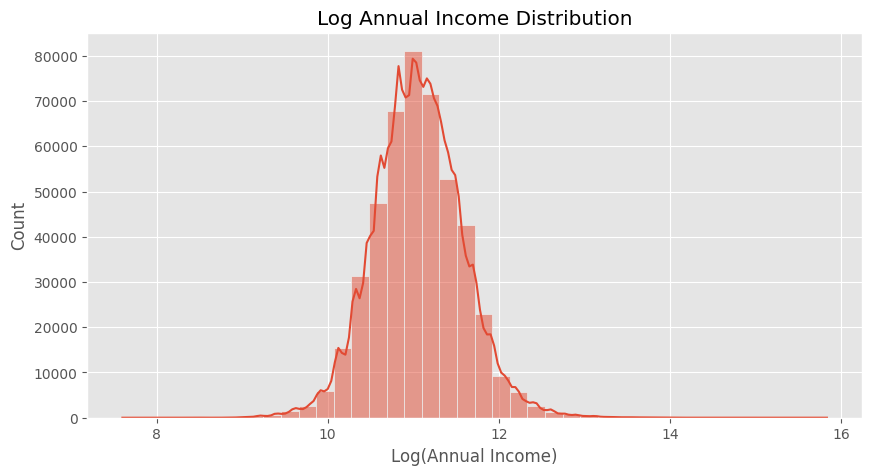

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(loan_clean['annual_inc']),
    bins=40,
    kde=True
)

plt.title("Log Annual Income Distribution")
plt.xlabel("Log(Annual Income)")

plt.show()

Transformasi log digunakan untuk mengurangi pengaruh nilai ekstrem sehingga distribusi pendapatan lebih mudah dianalisis.

## 4.5 Distribusi Grade

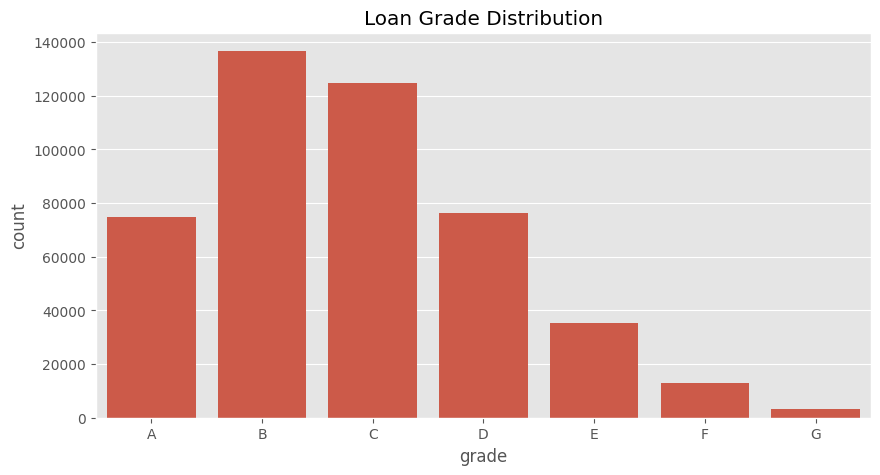

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='grade',
    data=loan_clean,
    order=sorted(loan_clean['grade'].unique())
)

plt.title("Loan Grade Distribution")

plt.show()

Grade B dan C mendominasi jumlah pinjaman, sedangkan Grade F dan G jumlahnya lebih sedikit.

## 4.6 Distribution of Loan Purpose

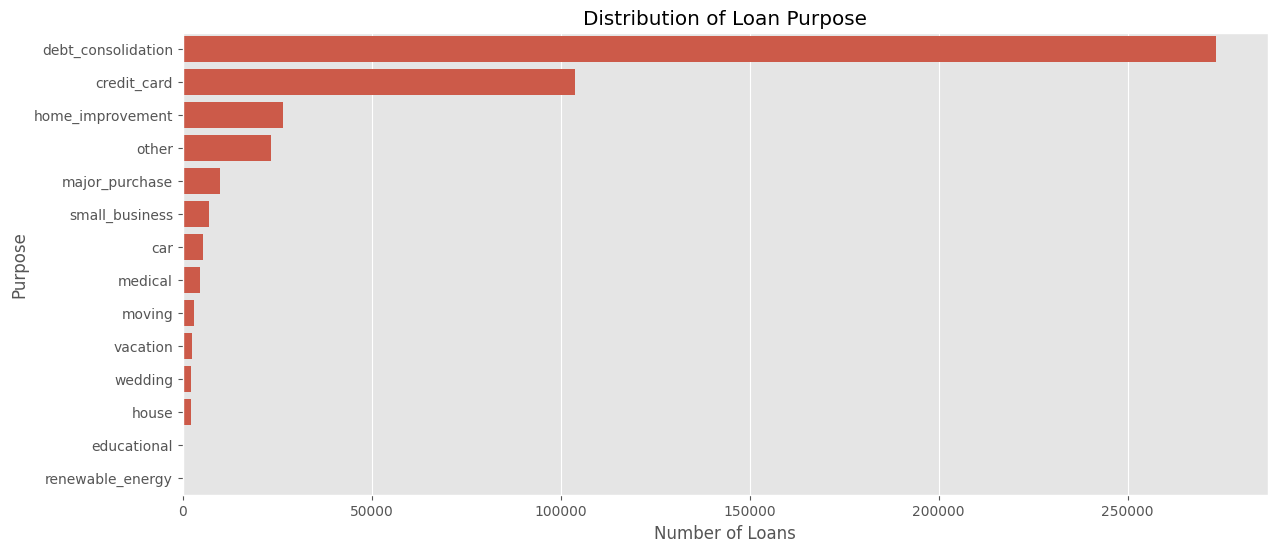

In [ ]:
plt.figure(figsize=(14,6))

sns.countplot(
    y='purpose',
    data=loan_clean,
    order=loan_clean['purpose'].value_counts().index
)

plt.title("Distribution of Loan Purpose")
plt.xlabel("Number of Loans")
plt.ylabel("Purpose")

plt.show()

Sebagian besar pinjaman digunakan untuk debt consolidation, diikuti oleh credit card refinancing dan home improvement. Hal ini menunjukkan bahwa mayoritas nasabah menggunakan pinjaman untuk mengelola kewajiban finansial yang sudah ada.

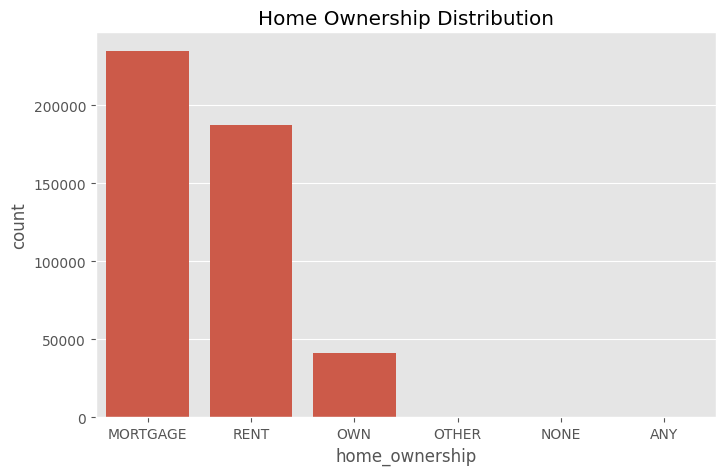

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='home_ownership',
    data=loan_clean,
    order=loan_clean['home_ownership'].value_counts().index
)

plt.title("Home Ownership Distribution")

plt.show()

Sebagian besar peminjam berada pada kategori Mortgage dan Rent, sedangkan kategori Own memiliki proporsi yang lebih kecil.

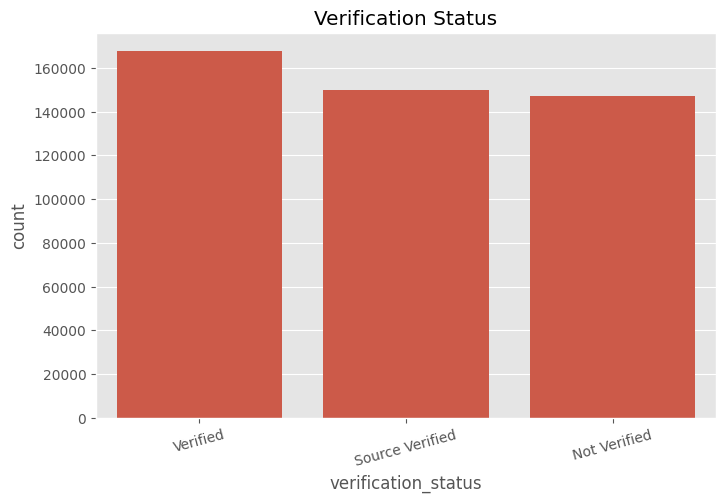

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='verification_status',
    data=loan_clean,
    order=loan_clean['verification_status'].value_counts().index
)

plt.title("Verification Status")

plt.xticks(rotation=15)

plt.show()

Sebagian besar peminjam telah melalui proses verifikasi atau memiliki status verifikasi tertentu sebelum pinjaman disetujui.

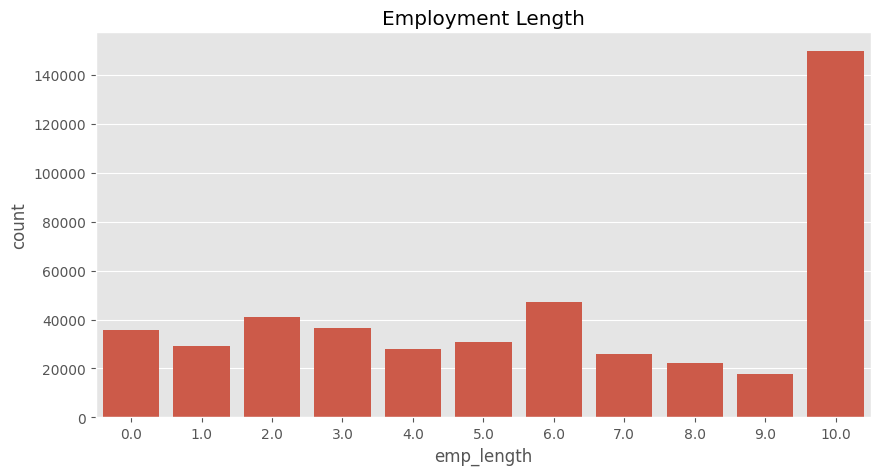

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='emp_length',
    data=loan_clean,
    order=sorted(loan_clean['emp_length'].dropna().unique())
)

plt.title("Employment Length")

plt.show()

Lama bekerja yang lebih tinggi umumnya menunjukkan stabilitas pekerjaan yang lebih baik. Variabel ini berpotensi menjadi salah satu indikator kemampuan membayar pinjaman.

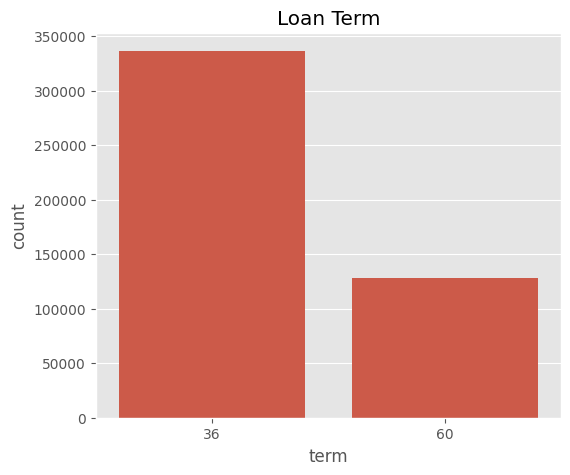

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='term',
    data=loan_clean
)

plt.title("Loan Term")

plt.show()

Sebagian besar pinjaman memiliki tenor 36 bulan, sedangkan tenor 60 bulan memiliki proporsi yang lebih kecil.

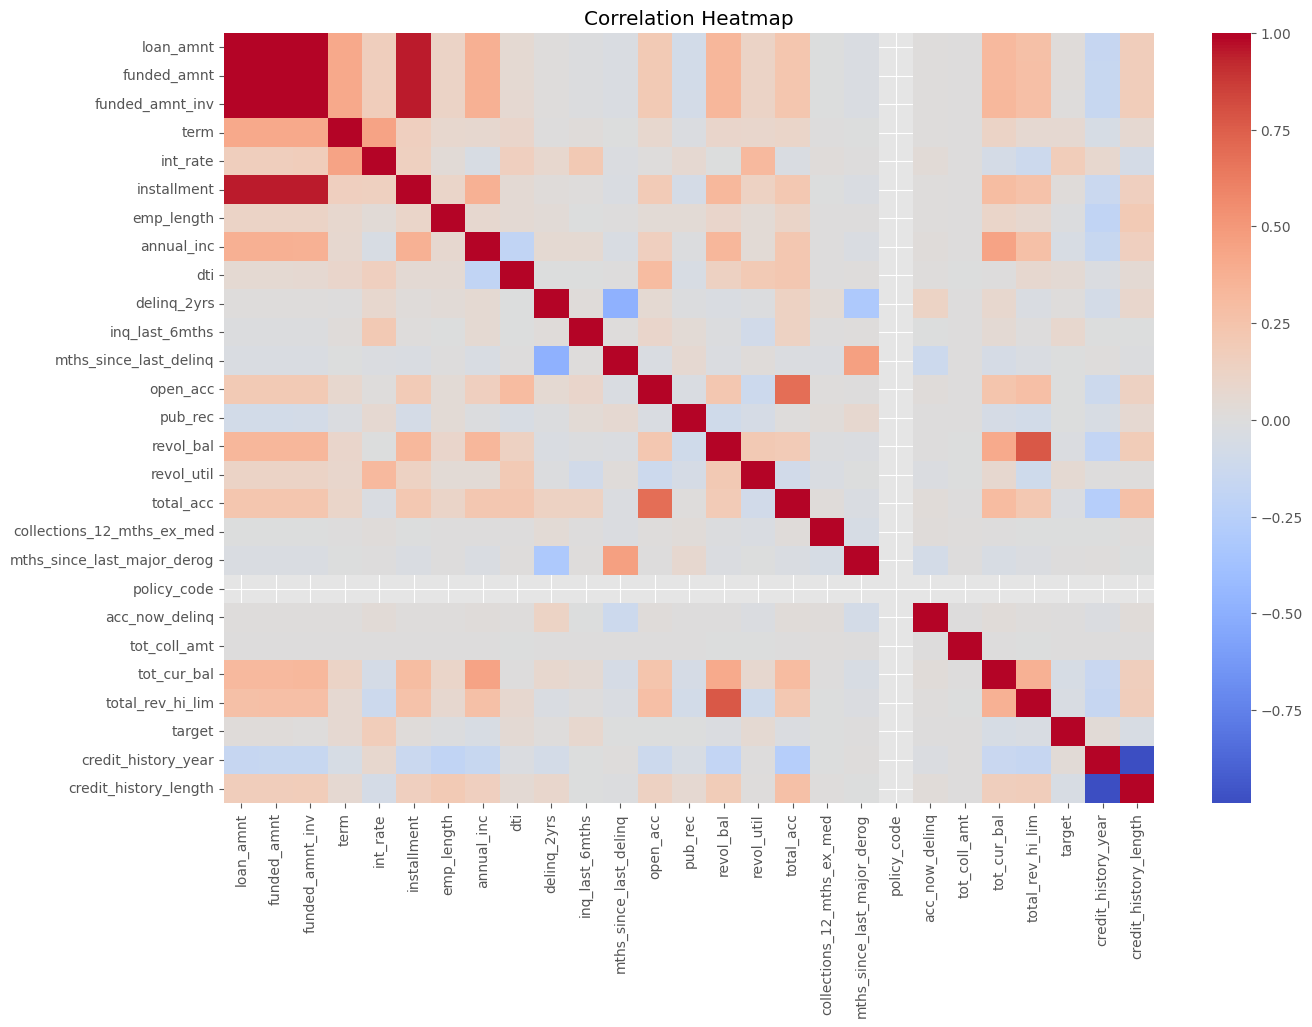

In [ ]:
plt.figure(figsize=(15,10))

corr = loan_clean.select_dtypes(
    include=['int64','float64']
).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

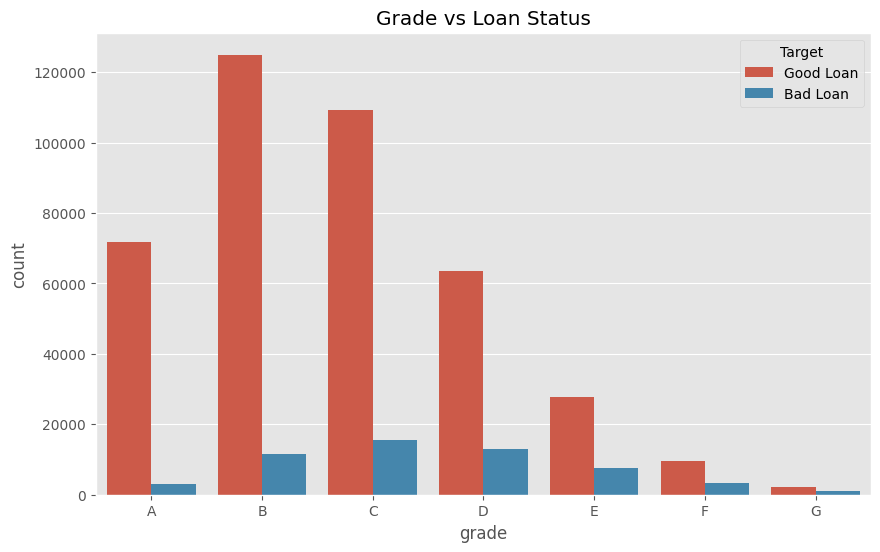

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='grade',
    hue='target',
    data=loan_clean,
    order=sorted(loan_clean['grade'].unique())
)

plt.title("Grade vs Loan Status")

plt.legend(
    title='Target',
    labels=['Good Loan','Bad Loan']
)

plt.show()

Grade A  Bad Loan sedikit
Grade G  Bad Loan banyak

Semakin rendah kualitas grade kredit, semakin besar proporsi Bad Loan. Hal ini menunjukkan bahwa sistem penilaian grade Lending Club sudah mencerminkan tingkat risiko peminjam.

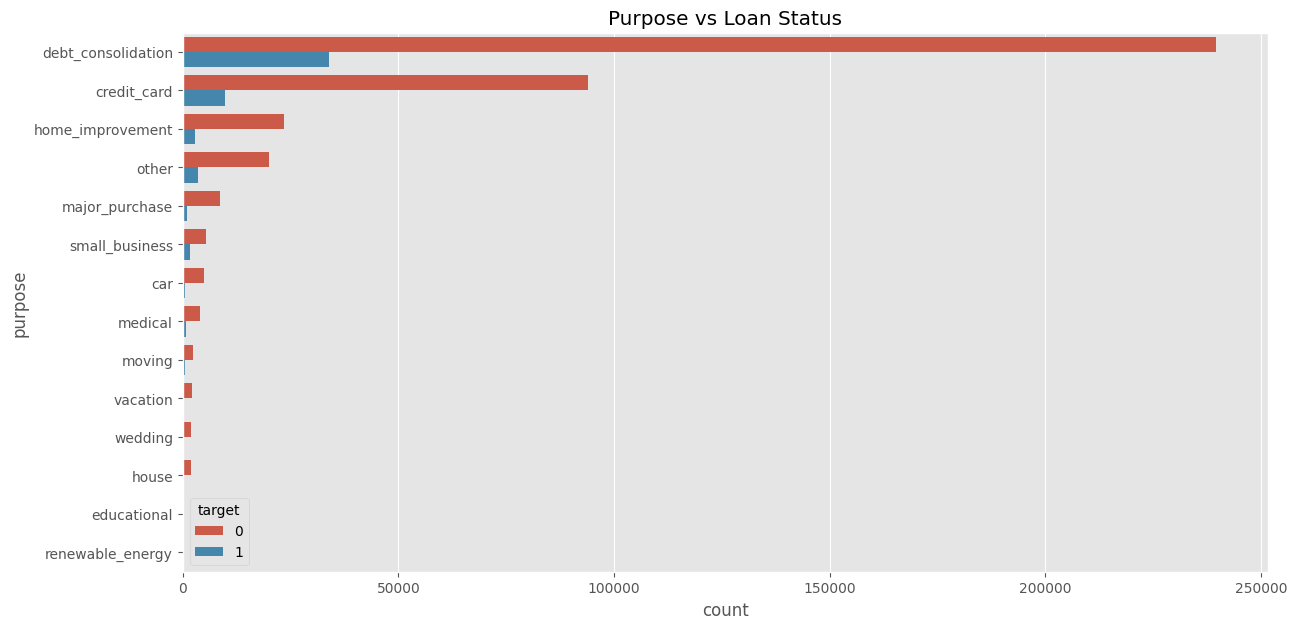

In [ ]:
plt.figure(figsize=(14,7))

sns.countplot(
    y='purpose',
    hue='target',
    data=loan_clean,
    order=loan_clean['purpose'].value_counts().index
)

plt.title("Purpose vs Loan Status")

plt.show()

Beberapa tujuan pinjaman memiliki proporsi Bad Loan yang lebih tinggi dibanding tujuan lainnya. Informasi ini dapat menjadi pertimbangan tambahan dalam proses persetujuan kredit.

In [ ]:
X = loan_clean.drop('target', axis=1)
y = loan_clean['target']

print(X.shape)
print(y.shape)

(464297, 38)
(464297,)


In [ ]:
X.dtypes.value_counts()

,count
float64,21
object,10
int64,5
int32,2


In [ ]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 10
Numerical: 28


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(371437, 38)
(92860, 38)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [ ]:
logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

In [ ]:
logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.6287
Precision: 0.1909
Recall   : 0.6532
F1 Score : 0.2954
ROC AUC  : 0.6929


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.63      0.75     81794
           1       0.19      0.65      0.30     11066

    accuracy                           0.63     92860
   macro avg       0.56      0.64      0.52     92860
weighted avg       0.84      0.63      0.69     92860



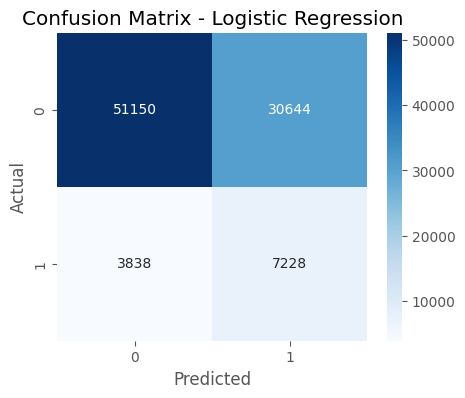

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
logreg_result = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
}

logreg_result

{'Accuracy': 0.6286668102519922,
 'Precision': 0.19085340092944655,
 'Recall': 0.6531718778239654,
 'F1': 0.29539417221790837,
 'ROC_AUC': np.float64(0.6928815400138961)}

### Logistic Regression Evaluation

Model Logistic Regression dengan parameter `class_weight='balanced'` menunjukkan peningkatan yang signifikan pada Recall dibandingkan model tanpa penyesuaian bobot kelas.

Meskipun Accuracy menurun, model mampu mendeteksi sekitar 65% pinjaman bermasalah (Bad Loan). Dalam konteks credit risk, kemampuan mendeteksi nasabah berisiko lebih penting dibandingkan hanya memperoleh Accuracy yang tinggi.

Oleh karena itu, model dengan `class_weight='balanced'` dipilih sebagai baseline sebelum membandingkannya dengan Random Forest.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'funded_amnt',
                                                   'funded_amnt_inv', 'term',
                                                   'int_rate', 'installment',
                                                   'emp_length', 'annual_inc',
                                                   'dti', 'delinq_2yrs',
                                                   'inq_last_6mths',
                                                   'mths_since_last_delinq',
                                                   'open_acc', 'pub_rec',
                                                   'r...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['grade', 'sub_grade',
                                                   'home_ownership',
                                                   'verification_status',
                                                   'pymnt_plan', 'purpose',
                                                   'zip_code', 'addr_state',
                                                   'initial_list_status',
                                                   'application_type'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
rf_result = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_prob_rf)
}

rf_result

{'Accuracy': 0.8810898126211502,
 'Precision': 0.875,
 'Recall': 0.0025302729080065064,
 'F1': 0.005045954225986664,
 'ROC_AUC': np.float64(0.6924849543890597)}

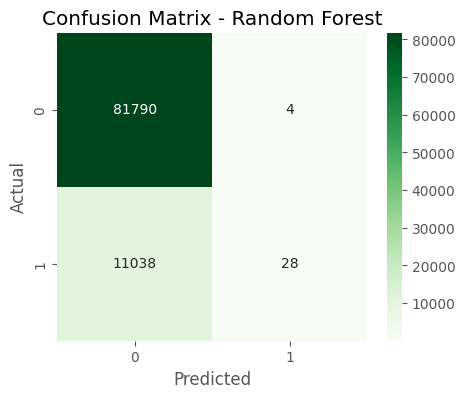

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [
        logreg_result["Accuracy"],
        logreg_result["Precision"],
        logreg_result["Recall"],
        logreg_result["F1"],
        logreg_result["ROC_AUC"]
    ],
    "Random Forest": [
        rf_result["Accuracy"],
        rf_result["Precision"],
        rf_result["Recall"],
        rf_result["F1"],
        rf_result["ROC_AUC"]
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.628667,0.881090
1,Precision,0.190853,0.875000
2,Recall,0.653172,0.002530
3,F1-Score,0.295394,0.005046
4,ROC-AUC,0.692882,0.692485


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt']
}

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

In [ ]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['loan_amnt',
                                                                                'funded_amnt',
                                                                                'funded_amnt_inv',
                                                                                'term',
                                                                                'int_rate',
                                                                                'installment',
                                                                                'emp_length',
                                                                                'annual_inc',
                                                                                'dti',
                                                                                'delinq_2yrs',
                                                                                'inq_last_6mths',
                                                                                'mths_since_la...
                                                                                'application_type'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [10, 20, None],
                                        'classifier__max_features': ['sqrt'],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5],
                                        'classifier__n_estimators': [200, 300]},
                   random_state=42, scoring='f1', verbose=1)

In [ ]:
best_rf = random_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

In [ ]:
rf_result = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_prob_rf)
}

rf_result

{'Accuracy': 0.7030288689067676,
 'Precision': 0.26707132018209406,
 'Recall': 0.5491419656786272,
 'F1': 0.35936702399183257,
 'ROC_AUC': np.float64(0.7000785470749373)}

# Conclusion

Berdasarkan hasil eksperimen, dilakukan perbandingan antara Logistic Regression dan Random Forest untuk memprediksi risiko gagal bayar pinjaman.

Model Logistic Regression dengan `class_weight='balanced'` mampu meningkatkan kemampuan mendeteksi kelas minoritas dibandingkan model tanpa penyesuaian.

Selanjutnya dilakukan Hyperparameter Tuning pada Random Forest menggunakan RandomizedSearchCV. Hasil tuning meningkatkan performa model dibandingkan Random Forest awal, terutama pada Recall, F1-Score, dan ROC-AUC.

Model terbaik pada penelitian ini adalah **Random Forest hasil Hyperparameter Tuning**, dengan performa sebagai berikut:

- Accuracy : 70.30%
- Precision : 26.71%
- Recall : 54.91%
- F1-Score : 35.94%
- ROC-AUC : 70.01%

Model ini dipilih karena memberikan keseimbangan yang lebih baik dalam mendeteksi pinjaman bermasalah (Bad Loan), sehingga lebih sesuai untuk kasus credit risk dibandingkan model yang hanya memiliki Accuracy tinggi.

# Business Recommendation

Berdasarkan hasil pemodelan, perusahaan dapat menggunakan model prediksi sebagai alat bantu dalam proses persetujuan pinjaman.

Beberapa rekomendasi yang dapat diterapkan antara lain:

- Melakukan evaluasi lebih lanjut terhadap calon peminjam yang diprediksi memiliki risiko gagal bayar tinggi.
- Menjadikan model sebagai sistem pendukung keputusan (decision support system), bukan sebagai pengganti keputusan analis kredit.
- Memperbarui model secara berkala menggunakan data terbaru agar performanya tetap optimal.
- Mengembangkan model lebih lanjut dengan teknik penanganan class imbalance, seperti SMOTE atau algoritma boosting, untuk meningkatkan kemampuan mendeteksi Bad Loan.